# Impact of Spatial Criterion
## 1. Setup

In [ ]:
import os, sys
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.getcwd())
import config

A_MIN = config.A_MIN
A_MIN_FIX = 2.0

m_per_deg = config.SCREEN_DIST_M * np.tan(np.radians(1))
PPD_X = config.SCREEN_RES[0]/config.SCREEN_SIZE_M[0] * m_per_deg
PPD_Y = config.SCREEN_RES[1]/config.SCREEN_SIZE_M[1] * m_per_deg
print(f"A_MIN={A_MIN} deg, PPD_X={PPD_X:.2f} PPD_Y={PPD_Y:.2f} px/deg")

A_MIN=1.0 deg, PPD_X=44.26 PPD_Y=44.76 px/deg


## 2. Load pre-merge data (sub-005)

In [2]:
DATA_PATH = r"C:\Users\chris\Documents\ArbeitUni\VIS_S-CCS\FreeViewing\BIDS\derivatives\in\sub-005\ses-001\misc\sub-005_ses-001_task-freeviewing_et_events.tsv"
df = pd.read_csv(DATA_PATH, sep="\t")
print("length:", len(df))
print(df.trial_type.value_counts().to_dict())

length: 32948
{'fixation': 15179, 'saccade': 15159, 'blink': 2610}


## 3. Merge function WITH spatial criterion

In [ ]:
SCREEN_RES    = (1920, 1080)
SCREEN_SIZE_M = (0.552, 0.307)
SCREEN_DIST_M = 0.729

_M_PER_DEG = SCREEN_DIST_M * np.tan(np.radians(1.0))
PPD_X = SCREEN_RES[0] / SCREEN_SIZE_M[0] * _M_PER_DEG   # 44.26 px/deg
PPD_Y = SCREEN_RES[1] / SCREEN_SIZE_M[1] * _M_PER_DEG   # 44.77 px/deg
PPD   = (PPD_X + PPD_Y) / 2                                           # 44.51 px/deg


def eucl_dist(a, b):
    return float(np.hypot(b["fix_avg_x"] - a["fix_avg_x"],
                          b["fix_avg_y"] - a["fix_avg_y"]))


def merge_fixation_candidates_w_spatial(events, a_min=A_MIN, merge_threshold=None):
    events = events.copy()
    t_min_sac = (2.2 * a_min + 27) / 1000.0
    merge_threshold = t_min_sac if merge_threshold is None else merge_threshold/1000.0
    a_min_px = A_MIN_FIX * PPD                                    
    events = events.sort_values(["eye", "onset"]).reset_index(drop=True)
    events = events[~(
        (events["trial_type"] == "saccade")
        & (events["sacc_visual_angle"] < a_min)
        & (events["duration"] < t_min_sac)
    )].reset_index(drop=True)

    rows, i = [], 0
    while i < len(events):
        cur = events.iloc[i].copy()
        if (i < len(events) - 1
                and events.iloc[i]["trial_type"] == "fixation"
                and events.iloc[i+1]["trial_type"] == "fixation"
                and events.iloc[i]["eye"] == events.iloc[i+1]["eye"]
                and events.iloc[i+1]["onset"] - events.iloc[i]["end_time"] < merge_threshold
                and eucl_dist(events.iloc[i], events.iloc[i+1]) < a_min_px  # CRITERION
                ):
            j = i + 1
            dur_sum = cur["duration"]
            while (j < len(events)
                   and events.iloc[j]["trial_type"] == "fixation"
                   and events.iloc[j]["eye"] == cur["eye"]
                   and events.iloc[j]["onset"] - events.iloc[j-1]["end_time"] < merge_threshold
                   and eucl_dist(events.iloc[j-1], events.iloc[j]) < a_min_px  # (2) j-1, j
                   ):
                next_row = events.iloc[j]                      # (3) next -> next_row
                dur_sum += next_row["duration"]
                for c in ["fix_avg_x", "fix_avg_y", "fix_avg_pupil_size"]:
                    cur[c] = (cur[c]*(dur_sum-next_row["duration"]) + next_row[c]*next_row["duration"]) / dur_sum
                j += 1
            cur["end_time"] = next_row["end_time"]
            cur["duration"] = next_row["end_time"] - cur["onset"]
            rows.append(cur)
            i = j
        else:
            rows.append(cur)
            i += 1
    return pd.DataFrame(rows).sort_values("onset").reset_index(drop=True)

## 4. Merge function WITHOUT spatial criterion

In [14]:
def merge_fixation_candidates_wo_spatial(events, a_min=A_MIN, merge_threshold=None):
    events = events.copy()
    t_min_sac = (2.2 * a_min + 27) / 1000.0
    merge_threshold = t_min_sac if merge_threshold is None else merge_threshold/1000.0
    events = events.sort_values(["eye", "onset"]).reset_index(drop=True)
    events = events[~(
        (events["trial_type"] == "saccade")
        & (events["sacc_visual_angle"] < a_min)
        & (events["duration"] < t_min_sac)
    )].reset_index(drop=True)

    rows, i = [], 0
    while i < len(events):
        cur = events.iloc[i].copy()
        if (i < len(events) - 1
                and events.iloc[i]["trial_type"] == "fixation"
                and events.iloc[i+1]["trial_type"] == "fixation"
                and events.iloc[i]["eye"] == events.iloc[i+1]["eye"]
                and events.iloc[i+1]["onset"] - events.iloc[i]["end_time"] < merge_threshold
                # and interfix_dist_deg(events.iloc[i], events.iloc[i+1]) < a_min
                ):
            j = i + 1
            dur_sum = cur["duration"]
            while (j < len(events)
                   and events.iloc[j]["trial_type"] == "fixation"
                   and events.iloc[j]["eye"] == cur["eye"]
                   and events.iloc[j]["onset"] - events.iloc[j-1]["end_time"] < merge_threshold
                   # and interfix_dist_deg(events.iloc[i], events.iloc[i+1]) < a_min
                   ):
                next = events.iloc[j]
                dur_sum += next["duration"]
                for c in ["fix_avg_x", "fix_avg_y", "fix_avg_pupil_size"]:
                    cur[c] = (cur[c]*(dur_sum-next["duration"]) + next[c]*next["duration"]) / dur_sum
                j += 1

            cur["end_time"] = next["end_time"]
            cur["duration"] = next["end_time"] - cur["onset"]
            rows.append(cur)
            i = j
        else:
            rows.append(cur)
            i += 1
    return pd.DataFrame(rows).sort_values("onset").reset_index(drop=True)

## 5. Compare both mergers

In [ ]:
m_with = merge_fixation_candidates_w_spatial(df, A_MIN, merge_threshold=100)
m_without = merge_fixation_candidates_wo_spatial(df, A_MIN, merge_threshold=100)

In [ ]:
print(f"Number of fixations: ",
      f"\n\t with spatial criterion: {m_with["trial_type"].value_counts()["fixation"]}",
      f"\n\t without spatial criterion: {m_without["trial_type"].value_counts()["fixation"]}",
      f"\nDifference: {abs(m_with["trial_type"].value_counts()["fixation"] - m_without["trial_type"].value_counts()["fixation"])}"
      f"\nPercentage difference: {abs(m_with["trial_type"].value_counts()["fixation"] - m_without["trial_type"].value_counts()["fixation"]) / m_without["trial_type"].value_counts()["fixation"] * 100:.2f}%"
)

Number of fixations:  
	 with spatial criterion: 12210, merges: 5349 
	 without spatial criterion: 11685, merges: 6147 
Difference: 525


In [7]:
m_with

,onset,duration,end_time,trial_type,eye,fix_avg_x,fix_avg_y,fix_avg_pupil_size,sacc_start_x,sacc_start_y,sacc_end_x,sacc_end_y,sacc_visual_angle,peak_velocity
0,190.768637,0.407,191.174637,fixation,L,968.500000,532.600000,906.000000,NaN,NaN,NaN,NaN,NaN,NaN
1,190.768637,0.407,191.174637,fixation,R,964.400000,515.400000,787.000000,NaN,NaN,NaN,NaN,NaN,NaN
2,191.175637,0.024,191.198637,saccade,R,NaN,NaN,NaN,962.1,516.8,873.2,499.8,2.04,112.0
3,191.175637,0.032,191.206637,saccade,L,NaN,NaN,NaN,965.1,532.4,845.5,514.4,2.73,118.0
4,191.199637,0.311,191.510637,fixation,R,849.333333,503.366667,827.666667,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26482,3560.570910,0.083,3560.652910,fixation,L,485.000000,1110.600000,1339.000000,NaN,NaN,NaN,NaN,NaN,NaN
26483,3560.653910,0.064,3560.716910,saccade,L,NaN,NaN,NaN,485.2,1117.9,930.5,560.0,15.40,422.0
26484,3560.654910,0.065,3560.718910,saccade,R,NaN,NaN,NaN,477.2,998.8,974.8,508.9,15.10,429.0
26485,3560.717910,0.134,3560.850910,fixation,L,924.900000,559.000000,1343.000000,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
m_without

,onset,duration,end_time,trial_type,eye,fix_avg_x,fix_avg_y,fix_avg_pupil_size,sacc_start_x,sacc_start_y,sacc_end_x,sacc_end_y,sacc_visual_angle,peak_velocity
0,190.768637,0.407,191.174637,fixation,L,968.500000,532.600000,906.000000,NaN,NaN,NaN,NaN,NaN,NaN
1,190.768637,0.407,191.174637,fixation,R,964.400000,515.400000,787.000000,NaN,NaN,NaN,NaN,NaN,NaN
2,191.175637,0.024,191.198637,saccade,R,NaN,NaN,NaN,962.1,516.8,873.2,499.8,2.04,112.0
3,191.175637,0.032,191.206637,saccade,L,NaN,NaN,NaN,965.1,532.4,845.5,514.4,2.73,118.0
4,191.199637,0.311,191.510637,fixation,R,849.333333,503.366667,827.666667,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25957,3560.570910,0.083,3560.652910,fixation,L,485.000000,1110.600000,1339.000000,NaN,NaN,NaN,NaN,NaN,NaN
25958,3560.653910,0.064,3560.716910,saccade,L,NaN,NaN,NaN,485.2,1117.9,930.5,560.0,15.40,422.0
25959,3560.654910,0.065,3560.718910,saccade,R,NaN,NaN,NaN,477.2,998.8,974.8,508.9,15.10,429.0
25960,3560.717910,0.134,3560.850910,fixation,L,924.900000,559.000000,1343.000000,NaN,NaN,NaN,NaN,NaN,NaN


### 5.1 Plot
saturated colour = merged = real position shift; 
pale colour = unchanged, and the gap is for display only

Note: without_spatial is um 1pxl nach unten und with spatial um ein pixal nach oben verschoben; change the parameter `offset` in `plot_eye_trace_pre_post_processing` for different offset

In [76]:
# This code is angelehnt an plot_eye_trace_pre_post_processing() but modified with AI:
RAW_COLOR        = "#222222"
W_SPATIAL_COLOR  = "#9D0BC2";  W_SPATIAL_LIGHT  = "#DCB3EC"
WO_SPATIAL_COLOR = "#D3841C";  WO_SPATIAL_LIGHT = "#F5D3AC"


def differing_onsets(before, after):
    """Fixation onsets in `before` that were absorbed by a merge in `after`."""
    recs = []
    for eye in ["L", "R"]:
        b = before[(before["eye"] == eye) & (before["trial_type"] == "fixation")]
        a = after[(after["eye"] == eye) & (after["trial_type"] == "fixation")]
        kept = np.round(a["onset"].to_numpy(), 6)
        absorbed = b[~np.isin(np.round(b["onset"].to_numpy(), 6), kept)]
        recs += [(eye, t) for t in absorbed["onset"]]
    return pd.DataFrame(recs, columns=["eye", "t"])


def _step_trace(fix_df, pos_col):
    """Flat segment per fixation, connected across gaps."""
    t, p = [], []
    for _, r in fix_df.iterrows():
        t.extend([r["onset"], r["end_time"]])
        p.extend([r[pos_col], r[pos_col]])
    return t, p


def _merged_mask(fix_df, raw_keys):
    """True where a fixation's (onset, end_time) pair is absent from raw, i.e. it was merged."""
    keys = zip(np.round(fix_df["onset"], 6), np.round(fix_df["end_time"], 6))
    return np.array([k not in raw_keys for k in keys], dtype=bool)


def plot_eye_trace_pre_post_processing(
    events_before, events_after, events_raw, windows, pos_col="fix_avg_x", offset=1, gap_ms=150,
):
    """
    Eye trace over explicit windows: raw as the reference, the two merge
    variants as pale offset bands, merged fixations highlighted.

    Args:
        events_before: variant with MORE fixations (with spatial criterion).
        events_after: variant with FEWER fixations (without).
        events_raw: raw events — the reference trace.
        windows: {"L": [(t0, t1), ...], "R": [...]}
        pos_col: "fix_avg_x" or "fix_avg_y". Run both.
        offset: vertical separation of the variant bands, in pixels.

    Returns:
        dict: {f"{rank}-{eye}-{pos_col}": figure}
    """
    figs = {}

    for eye in ["L", "R"]:
        sel_eye = lambda d: d[(d["eye"] == eye) & (d["trial_type"] == "fixation")]
        raw, before, after = sel_eye(events_raw), sel_eye(events_before), sel_eye(events_after)

        # Set lookup, so the merged test is O(1) per fixation instead of a scan.
        raw_keys = set(zip(np.round(raw["onset"], 6), np.round(raw["end_time"], 6)))
        eye_label = "Left" if eye == "L" else "Right"

        for rank, (w_start, w_end) in enumerate(windows[eye]):
            fig, ax = plt.subplots(1, 1, figsize=(14, 5))

            # Interval overlap, not onset-only: a fixation already running at
            # w_start must be drawn, or the panel starts with a blank gap.
            win = lambda d: d[(d["end_time"] >= w_start) & (d["onset"] < w_end)]
            w_raw, w_before, w_after = win(raw), win(before), win(after)

            # --- shade stretches with no fixation data -------------------
            edges = [w_start, *w_raw["onset"], w_end]
            ends  = [w_start, *w_raw["end_time"]]
            first_gap = True
            for g_start, g_end in zip(ends, edges[1:]):
                if g_end - g_start > gap_ms / 1000.0:
                    ax.axvspan(max(g_start, w_start), min(g_end, w_end),
                               color="#EDEDED", zorder=0,
                               label="no data" if first_gap else "")
                    first_gap = False

            for df_v, off, light, strong, name in [
                (w_after,  -offset, WO_SPATIAL_LIGHT, WO_SPATIAL_COLOR, "without spatial"),
                (w_before,  offset, W_SPATIAL_LIGHT,  W_SPATIAL_COLOR,  "with spatial"),
            ]:
                t, p = _step_trace(df_v, pos_col)
                ax.plot(t, [v + off for v in p], "-", color=light, linewidth=3,
                        alpha=0.9, zorder=1, solid_capstyle="butt", label=name)

                merged = df_v[_merged_mask(df_v, raw_keys)]
                for k, (_, r) in enumerate(merged.iterrows()):
                    ax.hlines(r[pos_col] + off, r["onset"], r["end_time"],
                              colors=strong, linewidth=3, alpha=1.0, zorder=3,
                              capstyle="butt",
                              label=f"merged ({name})" if k == 0 else "")

            # Reference last, so it stays visible on top of both bands.
            t, p = _step_trace(w_raw, pos_col)
            ax.plot(t, p, "-", color=RAW_COLOR, linewidth=1.8, alpha=0.95, zorder=4,
                    label="raw (reference)")

            ax.set_xlim(w_start, w_end)
            ax.set_xlabel("Time (s)", fontsize=11)
            ax.set_ylabel(f"Position — {pos_col} (px)", fontsize=9)
            ax.set_title(
                f"{eye_label} Eye — {pos_col}  |  t=[{w_start:.2f}s, {w_end:.2f}s]",
                fontsize=10,
            )
            ax.grid(True, alpha=0.3)
            ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), fontsize=8, frameon=False)
            fig.tight_layout()

            figs[f"{rank}-{eye}-{pos_col}"] = fig
            plt.show()

    return figs

525 differing fixations: {'L': 277, 'R': 248}


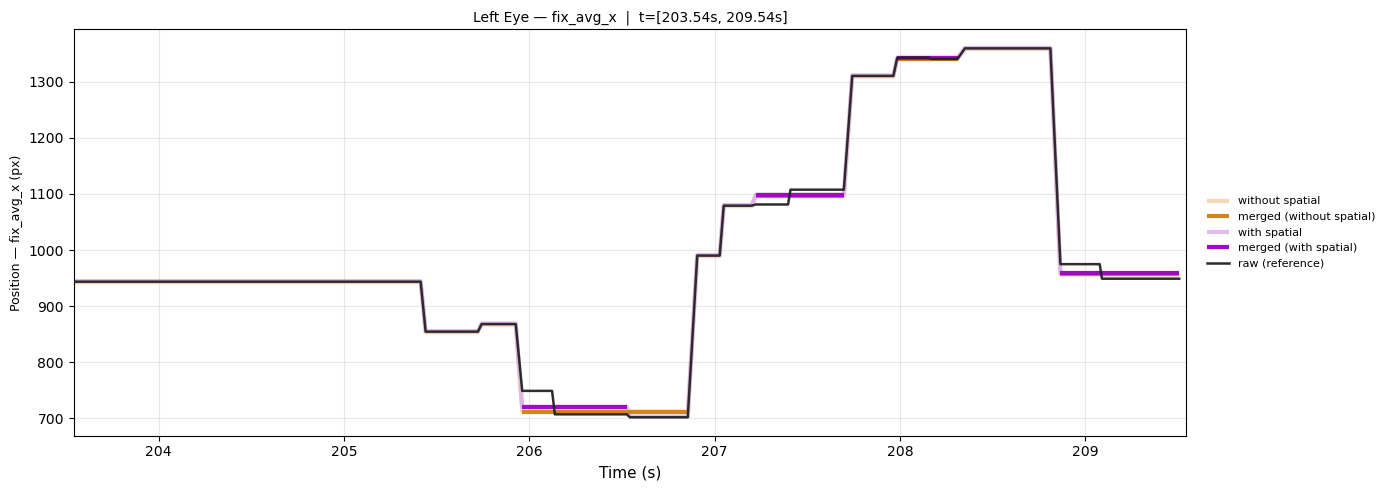

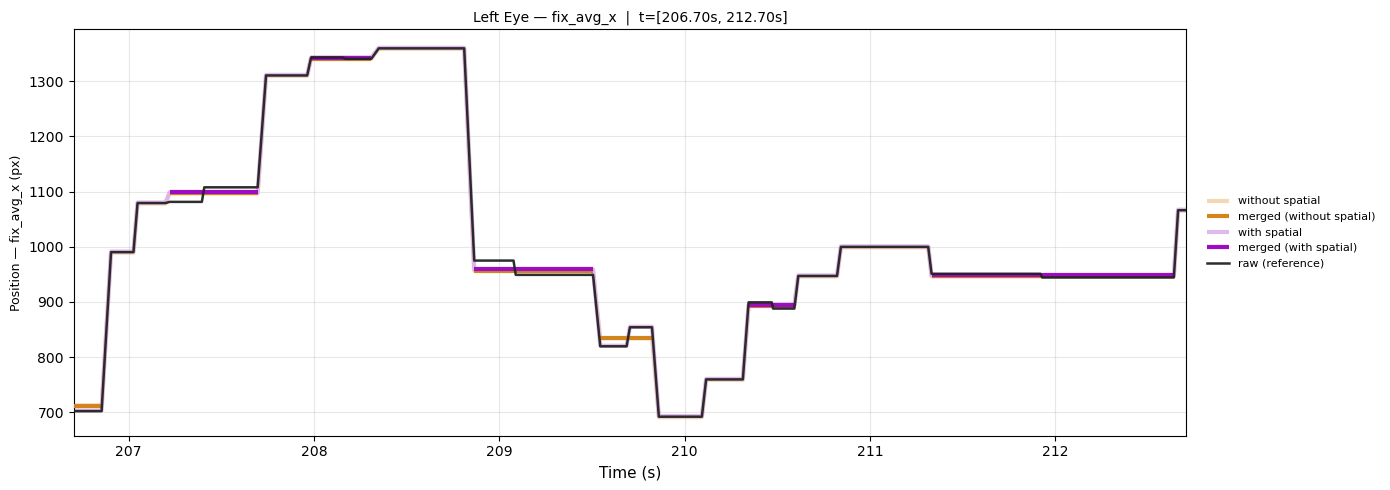

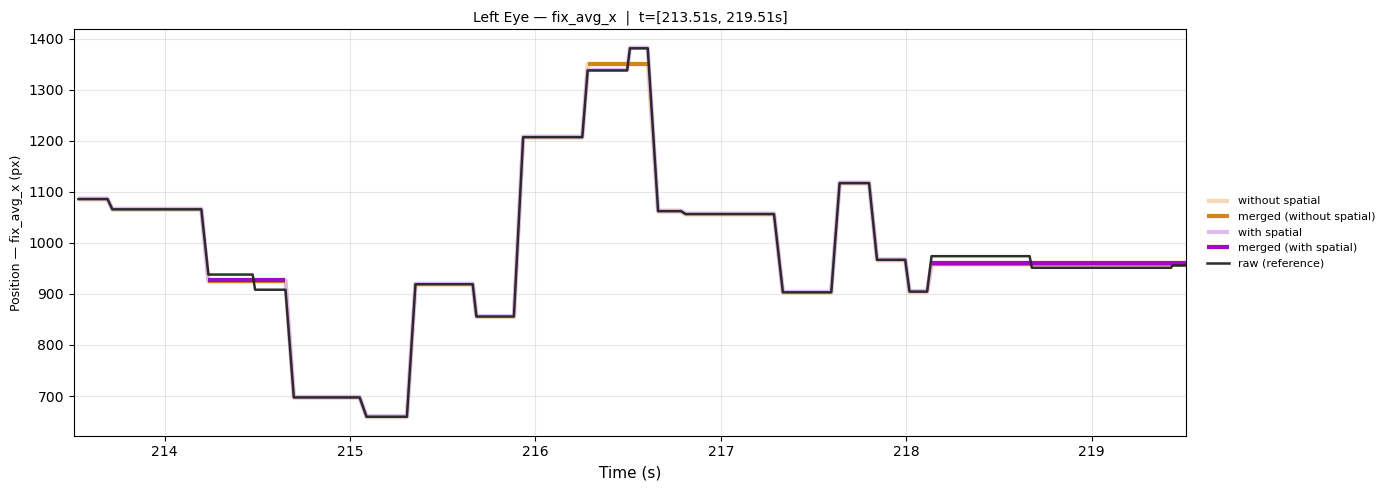

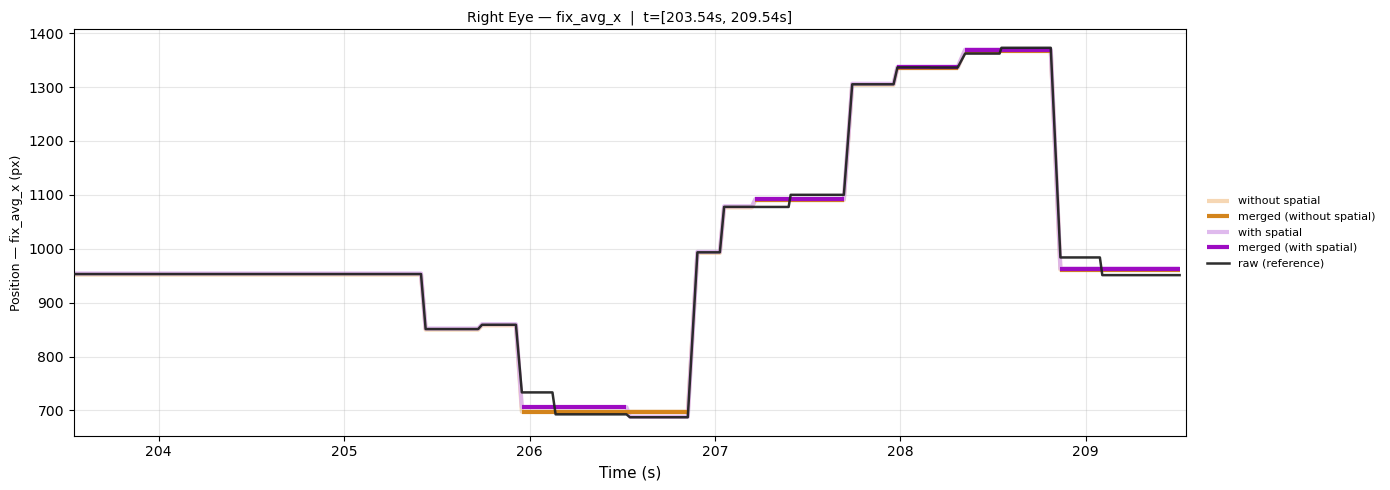

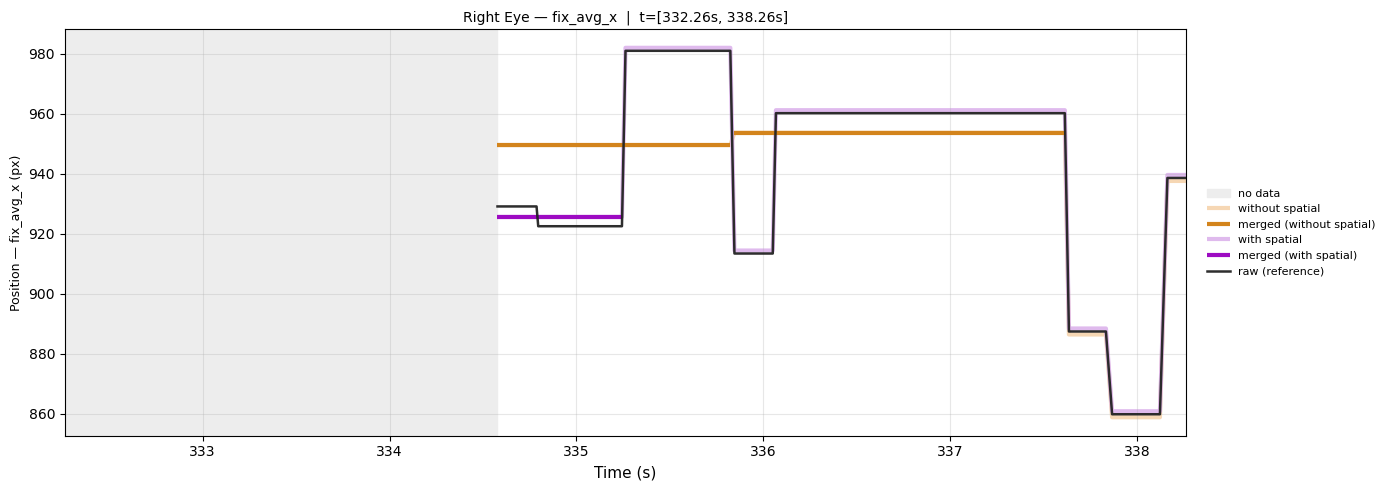

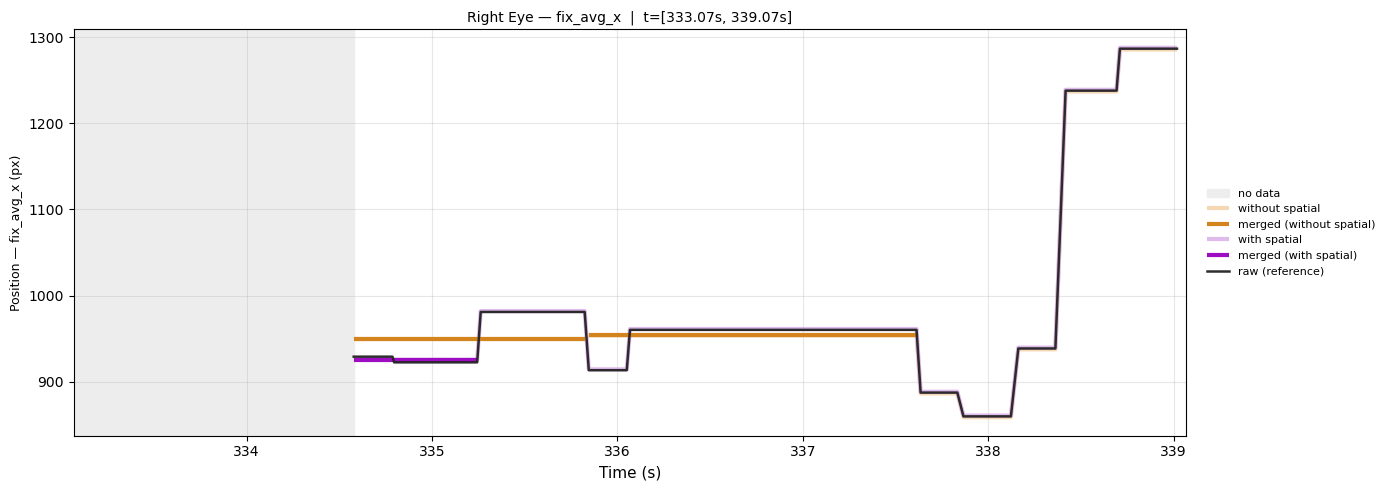

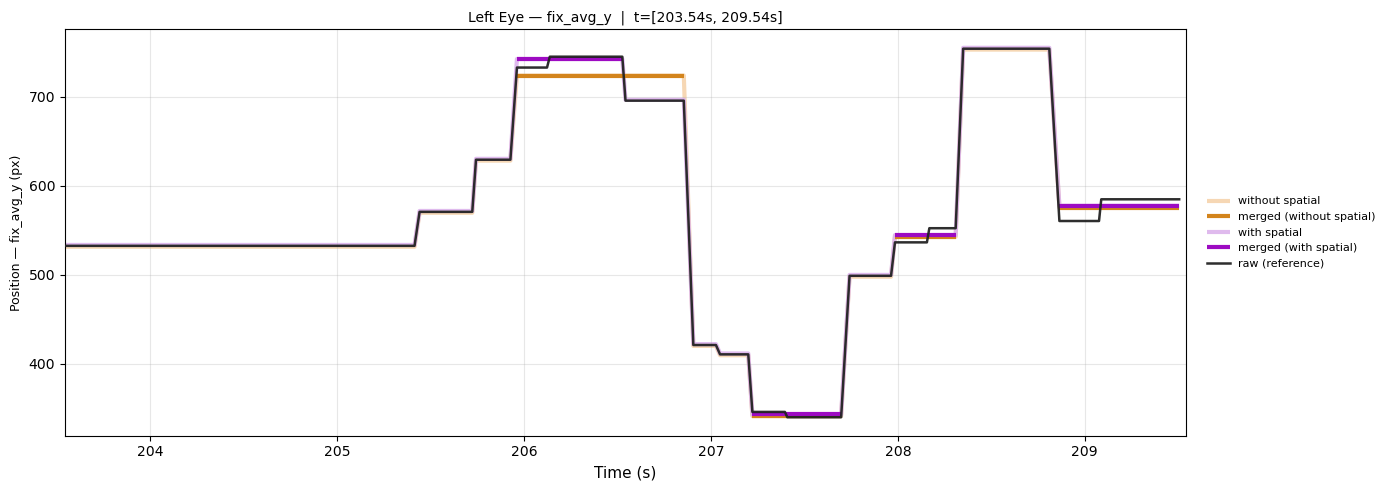

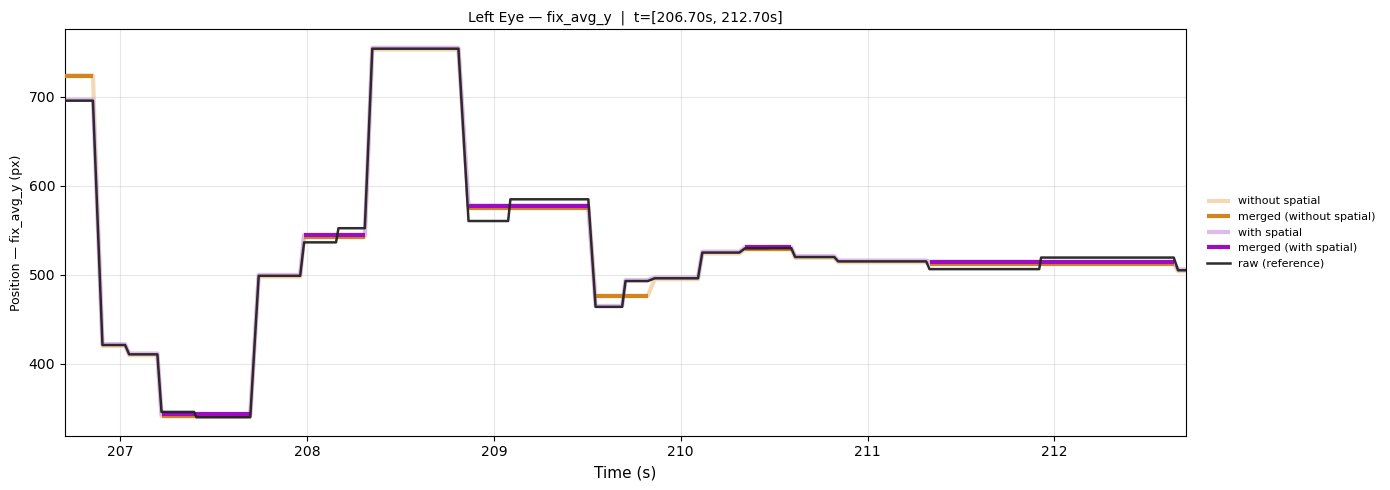

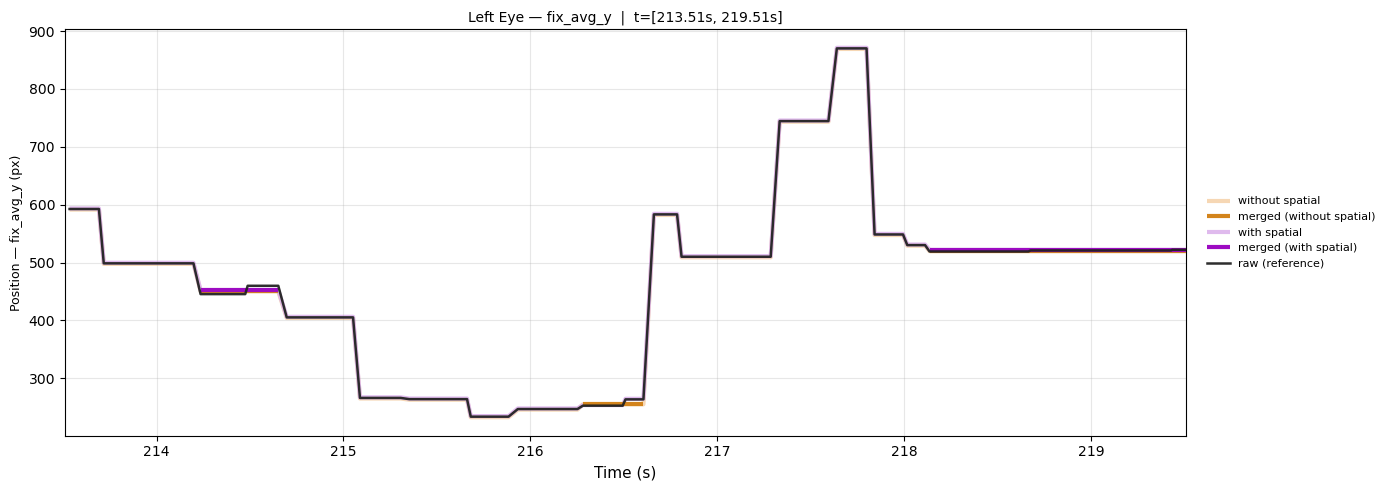

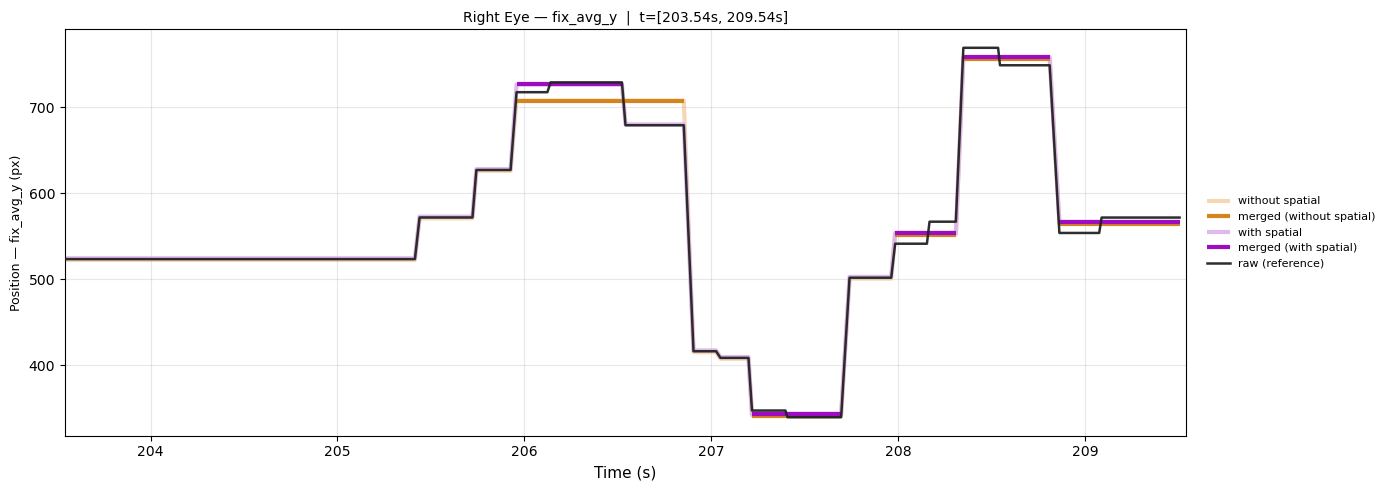

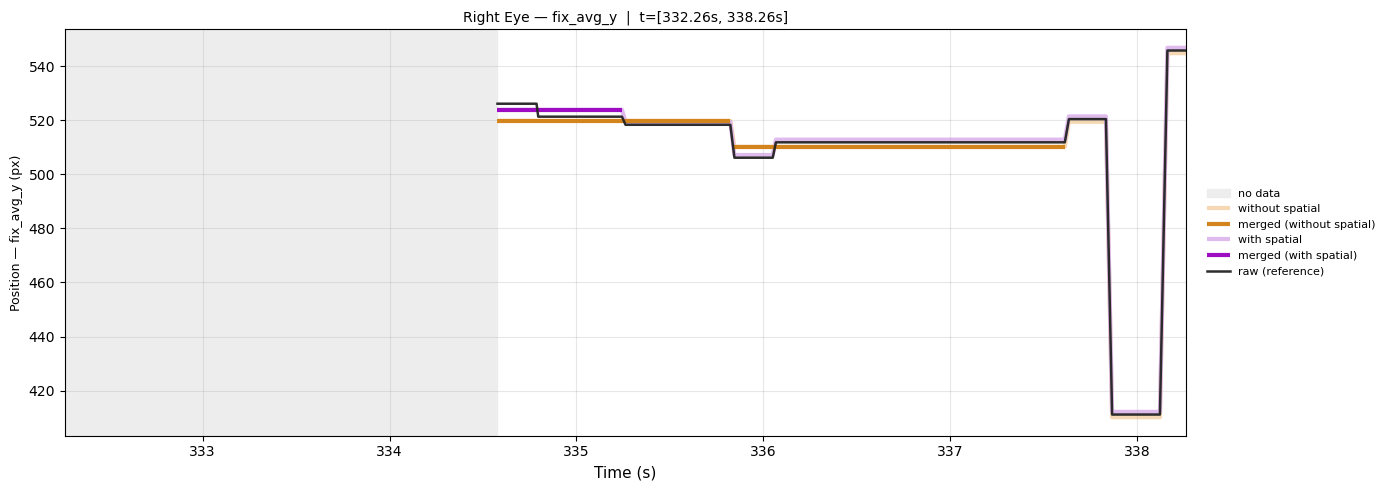

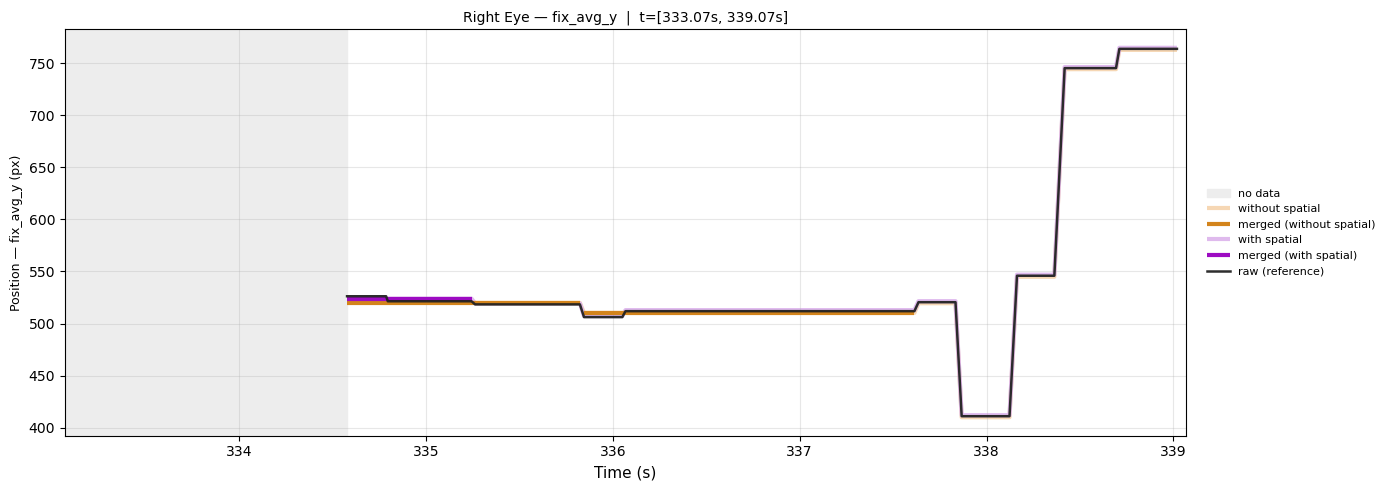

In [77]:
diff = differing_onsets(m_with, m_without)
print(f"{len(diff)} differing fixations:", diff.eye.value_counts().to_dict())

PAD, TOP_N = 3, 3
windows = {
    eye: [(t - PAD, t + PAD) for t in diff.loc[diff.eye == eye, "t"][:TOP_N]]
    for eye in ["L", "R"]
}

for col in ["fix_avg_x", "fix_avg_y"]:
    plot_eye_trace_pre_post_processing(
        m_with, m_without, df, windows,
        pos_col=col,
    )

# 6. Code to Calculate the Distance
and append as a new column to the Events Dataframe

Option 1: Distance from first to last fixation -> `merge_fixation_candidates_w_spatial_calc_first_last`
Option 2: max Distance between two consecutive fixations -> `merge_fixation_candidates_w_spatial_calc_max`

In [82]:
SCREEN_RES    = (1920, 1080)
SCREEN_SIZE_M = (0.552, 0.307)
SCREEN_DIST_M = 0.729

# # HERE: if the Spatial Criterion is applied (line 24 & 35), this needs to be added to config.py
_M_PER_DEG = SCREEN_DIST_M * np.tan(np.radians(1.0))
PPD_X = SCREEN_RES[0] / SCREEN_SIZE_M[0] * _M_PER_DEG   # 44.26 px/deg
PPD_Y = SCREEN_RES[1] / SCREEN_SIZE_M[1] * _M_PER_DEG   # 44.77 px/deg
PPD   = (PPD_X + PPD_Y) / 2                                           # 44.51 px/deg

# # HERE: if used this needs to be added to plotting.py
def eucl_dist(a, b):
    return float(np.hypot(b["fix_avg_x"] - a["fix_avg_x"],
                          b["fix_avg_y"] - a["fix_avg_y"]))

In [83]:
def merge_fixation_candidates_w_spatial_calc_first_last(events, a_min=A_MIN, merge_threshold=None,):
    events = events.copy()
    t_min_sac = (2.2 * a_min + 27) / 1000.0
    merge_threshold = t_min_sac if merge_threshold is None else merge_threshold / 1000.0
    # HERE: if the Spatial Criterion is applies (line 24 & 35), this needs to be changed to config.PPD
    a_min_px = a_min * PPD
    events = events.sort_values(["eye", "onset"]).reset_index(drop=True)
    events = events[~(
        (events["trial_type"] == "saccade")
        & (events["sacc_visual_angle"] < a_min)
        & (events["duration"] < t_min_sac)
    )].reset_index(drop=True)

    rows, i = [], 0

    while i < len(events):
        cur = events.iloc[i].copy()

        if (i < len(events) - 1
                and events.iloc[i]["trial_type"] == "fixation"
                and events.iloc[i+1]["trial_type"] == "fixation"
                and events.iloc[i]["eye"] == events.iloc[i+1]["eye"]
                and events.iloc[i+1]["onset"] - events.iloc[i]["end_time"] < merge_threshold
                #and (eucl_dist(events.iloc[i], events.iloc[i+1]) < a_min_px) # No Spatial Criterion
                ):
            # HERE: Insert this line in the code if you want it to calculate the distance between the first and the last merged fixation:
            # get the position of the potential first fixation of the fixation chain
            initial_position = events.iloc[i]
            j = i + 1
            dur_sum = cur["duration"]
            while (j < len(events)
                   and events.iloc[j]["trial_type"] == "fixation"
                   and events.iloc[j]["eye"] == cur["eye"]
                   and events.iloc[j]["onset"] - events.iloc[j-1]["end_time"] < merge_threshold
                   #and (eucl_dist(events.iloc[j-1], events.iloc[j]) < a_min_px) # No Spatial Criterion
                   ): 
                next_row = events.iloc[j]

                dur_sum += next_row["duration"]
                # weighted averaging of the position
                for c in ["fix_avg_x", "fix_avg_y", "fix_avg_pupil_size"]:
                    cur[c] = (cur[c]*(dur_sum-next_row["duration"])
                              + next_row[c]*next_row["duration"]) / dur_sum
                j += 1
            cur["end_time"] = next_row["end_time"]
            cur["duration"] = next_row["end_time"] - cur["onset"]
            # HERE: Insert this line in the code if you want it to calculate the distance between the first and the last merged fixation:
            # Calculate eucl. distance between first and last merged fixation
            cur["distance_merged"] = eucl_dist(initial_position, next_row)
            rows.append(cur)
            i = j
        else:
            rows.append(cur)
            i += 1

    merged = pd.DataFrame(rows).reset_index(drop=True)

    return merged.sort_values(["onset", "eye"], kind="stable").reset_index(drop=True)

In [ ]:
def merge_fixation_candidates_w_spatial_calc_max(events, a_min=A_MIN, merge_threshold=None,):
    events = events.copy()
    t_min_sac = (2.2 * a_min + 27) / 1000.0
    merge_threshold = t_min_sac if merge_threshold is None else merge_threshold / 1000.0
    # HERE: if the Spatial Criterion is applies (line 24 & 35), this needs to be changed to config.PPD
    a_min_px = a_min * PPD
    events = events.sort_values(["eye", "onset"]).reset_index(drop=True)
    events = events[~(
        (events["trial_type"] == "saccade")
        & (events["sacc_visual_angle"] < a_min)
        & (events["duration"] < t_min_sac)
    )].reset_index(drop=True)

    rows, i = [], 0

    while i < len(events):
        cur = events.iloc[i].copy()
        # HERE: Insert this line in the code if you want it to calculate the max distance in the fixation chain:
        # collect distances in this fixation chain
        dists = [] 

        if (i < len(events) - 1
                and events.iloc[i]["trial_type"] == "fixation"
                and events.iloc[i+1]["trial_type"] == "fixation"
                and events.iloc[i]["eye"] == events.iloc[i+1]["eye"]
                and events.iloc[i+1]["onset"] - events.iloc[i]["end_time"] < merge_threshold
                #and (eucl_dist(events.iloc[i], events.iloc[i+1]) < a_min_px) # No Spatial Criterion
                ):
            j = i + 1
            dur_sum = cur["duration"]
            while (j < len(events)
                   and events.iloc[j]["trial_type"] == "fixation"
                   and events.iloc[j]["eye"] == cur["eye"]
                   and events.iloc[j]["onset"] - events.iloc[j-1]["end_time"] < merge_threshold
                   #and (eucl_dist(events.iloc[j-1], events.iloc[j]) < a_min_px) # No Spatial Criterion
                   ): 
                next_row = events.iloc[j]
                # HERE: Insert this line in the code if you want it to calculate the max distance in the fixation chain:
                # Calculate eucl. distance between the current and next fixation
                dists.append(eucl_dist(events.iloc[j-1], next_row))

                dur_sum += next_row["duration"]
                # weighted averaging of the position
                for c in ["fix_avg_x", "fix_avg_y", "fix_avg_pupil_size"]:
                    cur[c] = (cur[c]*(dur_sum-next_row["duration"])
                              + next_row[c]*next_row["duration"]) / dur_sum
                j += 1
            cur["end_time"] = next_row["end_time"]
            cur["duration"] = next_row["end_time"] - cur["onset"]
            # HERE: Insert this line in the code if you want it to calculate the distance between the first and the last merged fixation:
            # Get the biggest distance that is bridged between two merged fixations, if the list is not empty
            cur["max_distance_merged"] = cur["max_distance_merged"] = max(dists) if dists else np.nan
            rows.append(cur)
            i = j
        else:
            rows.append(cur)
            i += 1

    merged = pd.DataFrame(rows).reset_index(drop=True)

    return merged.sort_values(["onset", "eye"], kind="stable").reset_index(drop=True)

In [84]:
m_dist = merge_fixation_candidates_w_spatial_calc_first_last(df, A_MIN, merge_threshold=100)
m_max_dist = merge_fixation_candidates_w_spatial_calc_max(df, A_MIN, merge_threshold=100)

In [85]:
m_dist

,onset,duration,end_time,trial_type,eye,fix_avg_x,fix_avg_y,fix_avg_pupil_size,sacc_start_x,sacc_start_y,sacc_end_x,sacc_end_y,sacc_visual_angle,peak_velocity,distance_merged
0,190.768637,0.407,191.174637,fixation,L,968.500000,532.600000,906.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,190.768637,0.407,191.174637,fixation,R,964.400000,515.400000,787.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,191.175637,0.032,191.206637,saccade,L,NaN,NaN,NaN,965.1,532.4,845.5,514.4,2.73,118.0,NaN
3,191.175637,0.024,191.198637,saccade,R,NaN,NaN,NaN,962.1,516.8,873.2,499.8,2.04,112.0,NaN
4,191.199637,0.311,191.510637,fixation,R,849.333333,503.366667,827.666667,NaN,NaN,NaN,NaN,NaN,NaN,34.492463
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25957,3560.570910,0.083,3560.652910,fixation,L,485.000000,1110.600000,1339.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25958,3560.653910,0.064,3560.716910,saccade,L,NaN,NaN,NaN,485.2,1117.9,930.5,560.0,15.40,422.0,NaN
25959,3560.654910,0.065,3560.718910,saccade,R,NaN,NaN,NaN,477.2,998.8,974.8,508.9,15.10,429.0,NaN
25960,3560.717910,0.134,3560.850910,fixation,L,924.900000,559.000000,1343.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [86]:
m_max_dist

,onset,duration,end_time,trial_type,eye,fix_avg_x,fix_avg_y,fix_avg_pupil_size,sacc_start_x,sacc_start_y,sacc_end_x,sacc_end_y,sacc_visual_angle,peak_velocity,max_distance_merged
0,190.768637,0.407,191.174637,fixation,L,968.500000,532.600000,906.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,190.768637,0.407,191.174637,fixation,R,964.400000,515.400000,787.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,191.175637,0.032,191.206637,saccade,L,NaN,NaN,NaN,965.1,532.4,845.5,514.4,2.73,118.0,NaN
3,191.175637,0.024,191.198637,saccade,R,NaN,NaN,NaN,962.1,516.8,873.2,499.8,2.04,112.0,NaN
4,191.199637,0.311,191.510637,fixation,R,849.333333,503.366667,827.666667,NaN,NaN,NaN,NaN,NaN,NaN,34.492463
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25957,3560.570910,0.083,3560.652910,fixation,L,485.000000,1110.600000,1339.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25958,3560.653910,0.064,3560.716910,saccade,L,NaN,NaN,NaN,485.2,1117.9,930.5,560.0,15.40,422.0,NaN
25959,3560.654910,0.065,3560.718910,saccade,R,NaN,NaN,NaN,477.2,998.8,974.8,508.9,15.10,429.0,NaN
25960,3560.717910,0.134,3560.850910,fixation,L,924.900000,559.000000,1343.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
